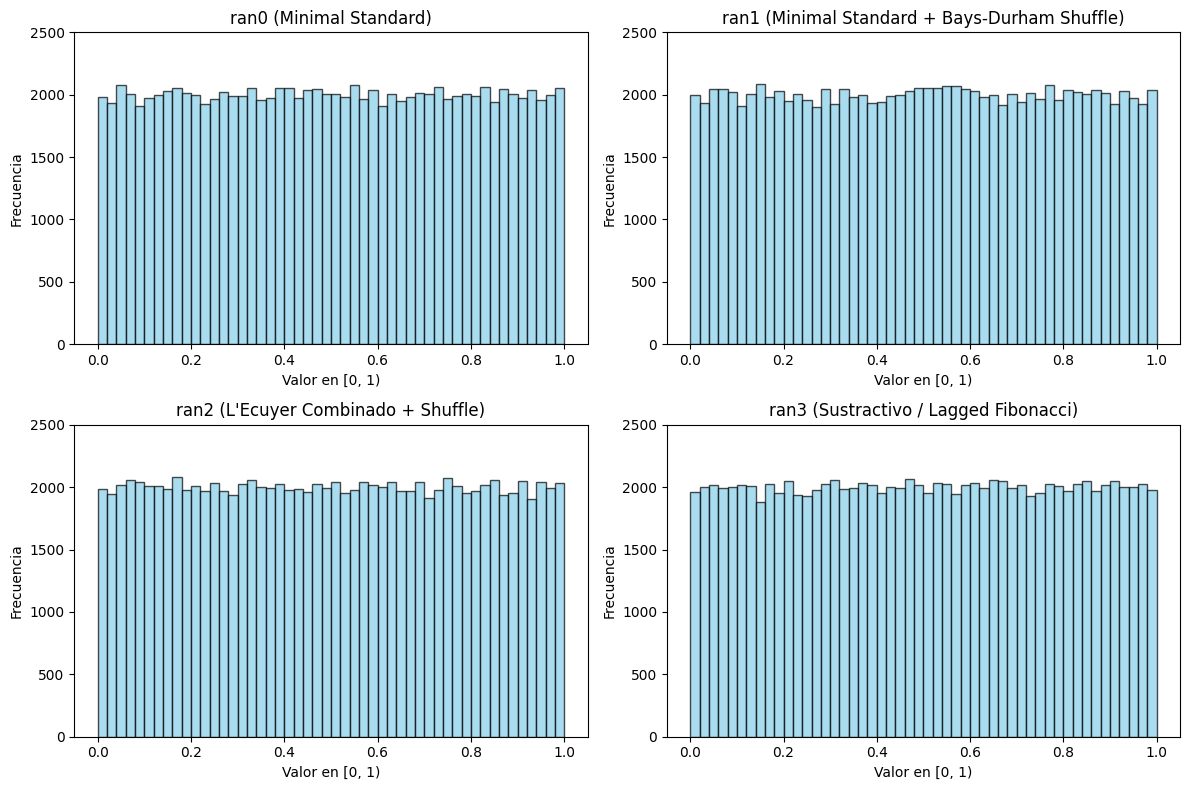

In [2]:
import numpy as np
import matplotlib.pyplot as plt

class NumericalRecipesRNG:
    def __init__(self, seed=-123456789):
        # Semilla inicial (debe ser negativa para inicializar ran1, ran2 y ran3)
        self.idum = seed
        self.idum2 = 123456789
        self.iy = 0
        self.iv = [0] * 32

        # Estado interno para ran3
        self.inext = 0
        self.inextp = 0
        self.ma = [0] * 56
        self.iff = 0

    def ran0(self):
        """Minimal Standard de Park y Miller (Sección 7.1)"""
        IA = 16807
        IM = 2147483647
        AM = 1.0 / IM
        IQ = 127773
        IR = 2836
        MASK = 123459876

        self.idum ^= MASK
        k = self.idum // IQ
        self.idum = IA * (self.idum - k * IQ) - IR * k
        if self.idum < 0:
            self.idum += IM
        ans = AM * self.idum
        self.idum ^= MASK
        return ans

    def ran1(self):
        """Minimal Standard con desordenamiento de Bays-Durham (Sección 7.1)"""
        IA = 16807
        IM = 2147483647
        AM = 1.0 / IM
        IQ = 127773
        IR = 2836
        NTAB = 32
        NDIV = 1 + (IM - 1) // NTAB
        RNMX = 1.0 - 1.2e-7

        if self.idum <= 0 or self.iy == 0:
            if -self.idum < 1:
                self.idum = 1
            else:
                self.idum = -self.idum

            for j in range(NTAB + 7, -1, -1):
                k = self.idum // IQ
                self.idum = IA * (self.idum - k * IQ) - IR * k
                if self.idum < 0:
                    self.idum += IM
                if j < NTAB:
                    self.iv[j] = self.idum
            self.iy = self.iv[0]

        k = self.idum // IQ
        self.idum = IA * (self.idum - k * IQ) - IR * k
        if self.idum < 0:
            self.idum += IM

        j = self.iy // NDIV
        self.iy = self.iv[j]
        self.iv[j] = self.idum
        temp = AM * self.iy
        return min(temp, RNMX)

    def ran2(self):
        """Generador combinado de L'Ecuyer con desordenamiento (Sección 7.1)"""
        IM1 = 2147483563
        IM2 = 2147483399
        AM = 1.0 / IM1
        IMM1 = IM1 - 1
        IA1 = 40014
        IA2 = 40692
        IQ1 = 53668
        IQ2 = 52774
        IR1 = 12211
        IR2 = 3791
        NTAB = 32
        NDIV = 1 + IMM1 // NTAB
        RNMX = 1.0 - 1.2e-7

        if self.idum <= 0:
            if -self.idum < 1:
                self.idum = 1
            else:
                self.idum = -self.idum
            self.idum2 = self.idum

            for j in range(NTAB + 7, -1, -1):
                k = self.idum // IQ1
                self.idum = IA1 * (self.idum - k * IQ1) - k * IR1
                if self.idum < 0:
                    self.idum += IM1
                if j < NTAB:
                    self.iv[j] = self.idum
            self.iy = self.iv[0]

        k = self.idum // IQ1
        self.idum = IA1 * (self.idum - k * IQ1) - k * IR1
        if self.idum < 0:
            self.idum += IM1

        k = self.idum2 // IQ2
        self.idum2 = IA2 * (self.idum2 - k * IQ2) - k * IR2
        if self.idum2 < 0:
            self.idum2 += IM2

        j = self.iy // NDIV
        self.iy = self.iv[j] - self.idum2
        self.iv[j] = self.idum
        if self.iy < 1:
            self.iy += IMM1

        temp = AM * self.iy
        return min(temp, RNMX)

    def ran3(self):
        """Generador sustractivo / Lagged Fibonacci de Knuth (Sección 7.1)"""
        MBIG = 1000000000
        MSEED = 161803398
        MZ = 0
        FAC = 1.0 / MBIG

        if self.idum < 0 or self.iff == 0:
            self.iff = 1
            mj = abs(MSEED - abs(self.idum)) % MBIG
            self.ma[55] = mj
            mk = 1
            for i in range(1, 55):
                ii = (21 * i) % 55
                self.ma[ii] = mk
                mk = mj - mk
                if mk < MZ:
                    mk += MBIG
                mj = self.ma[ii]

            for k in range(1, 5):
                for i in range(1, 56):
                    self.ma[i] -= self.ma[1 + (i + 30) % 55]
                    if self.ma[i] < MZ:
                        self.ma[i] += MBIG

            self.inext = 0
            self.inextp = 31
            self.idum = 1

        self.inext += 1
        if self.inext == 56:
            self.inext = 1
        self.inextp += 1
        if self.inextp == 56:
            self.inextp = 1

        mj = self.ma[self.inext] - self.ma[self.inextp]
        if mj < MZ:
            mj += MBIG
        self.ma[self.inext] = mj
        return mj * FAC

# ==========================================
# GENERACIÓN DE MUESTRAS Y EVALUACIÓN
# ==========================================

N = 100000  # Generar 100,000 números por cada algoritmo
rng = NumericalRecipesRNG(seed=-987654321)

data_ran0 = [rng.ran0() for _ in range(N)]
data_ran1 = [rng.ran1() for _ in range(N)]
data_ran2 = [rng.ran2() for _ in range(N)]
data_ran3 = [rng.ran3() for _ in range(N)]

generators = {
    "ran0 (Minimal Standard)": data_ran0,
    "ran1 (Minimal Standard + Bays-Durham Shuffle)": data_ran1,
    "ran2 (L'Ecuyer Combinado + Shuffle)": data_ran2,
    "ran3 (Sustractivo / Lagged Fibonacci)": data_ran3
}

# Graficar Histogramas
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for idx, (title, data) in enumerate(generators.items()):
    axes[idx].hist(data, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(title)
    axes[idx].set_xlabel("Valor en [0, 1)")
    axes[idx].set_ylabel("Frecuencia")
    axes[idx].set_ylim(0, (N / 50) * 1.25)

plt.tight_layout()
plt.show()